<img src="images/top_banner_ML1_HW1.png" style="width: 100%;">

<h1 style='text-align: center;'><i><b>Machine Learning for Oenophiles:</i></b></h1>
<h2 style='text-align: center;'><i>Binary Classification of Wines for Bottling Process Automation using K-Nearest Neighbors</i></h2>

---
### **COSCI221 - Machine Learning 1**
**Dr. Kenneth T. Co, PhD**
  
*Homework 1*

**<u>MSDS 2026 Learning Team 8, Term 2,</u>**

- Francis Erdey M. Capati
   
- Kevin Ansel S. Dy

- Jan Paolo V. Moreno

- Mia Cielo G. Oliveros

                                                              
---

## Background
 
<p align="justify">Part of the wine manufacturing process is wine bottling. In this step, a bulk storage tank containing wine is 
transferred to a bottling factory and placed in wine bottles (Mohais et. al, 2012, p. 39).</p>
 
<p align="justify">A bottling factory contains bottling lines which are machines that are directly connected to the tank, and is used to transfer the wine into glass bottles (Mohais et. al, 2012, p. 39). For most companies, it is impractical to have individual machines exclusively for each type of wine. As such, one machine is used at different times to bottle different types of wine. The process of switching from one wine type to another type is called _wine changeover_ (Mohais et. al, 2012, p. 41).</p>
 
### Problem: 
Create a model that predicts the wine type by classifying as red wine or white wine

## Import necessary libraries

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

## Load dataset

In [82]:
df = pd.read_csv('wine_quality_merged.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## Initial information about the dataset

The dataset contains 6497 samples with 13 features that describes their chemical properties and quality.

In [6]:
df.shape

(6497, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [8]:
df.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4898
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,NaN
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,NaN
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,NaN
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,NaN
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,NaN
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,NaN


## Features and Target

### 1. Acidity/complexity (Fixed acidity, volatile acidity, citric acid, pH)

#### Fixed acidity
Description:

#### Volatile acidity
Description:

#### Citric acid
Description:

#### pH
Description:

### 2.Fermentation and Texture/Body (Alcohols, Residual sugars, Density)

#### Alcohol
Description:

#### Residual sugar
Description:

#### Density
Description:

### 3. Preservation/stability (Free sulphate, Total sulphate, Sulphates)

#### Free sulfur dioxide
Description:

#### Total sulfur dioxide
Description:

#### Sulphates
Description:

### 4. Unique Characteristic/Context (Chlorides, Type, Quality)

#### Chlorides
Description:

#### Type
Description:

#### Quality
Description:




In [9]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9])

In [10]:
df['type'].unique()

array(['red', 'white'], dtype=object)

In [11]:
df.nunique() #Count of unique values per column

fixed acidity           106
volatile acidity        187
citric acid              89
residual sugar          316
chlorides               214
free sulfur dioxide     135
total sulfur dioxide    276
density                 998
pH                      108
sulphates               111
alcohol                 111
quality                   7
type                      2
dtype: int64

In [12]:
df.isna().any() #Checking if there is NaN

fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
type                    False
dtype: bool

# Distribution of Features per Type

### Fixed Acidity

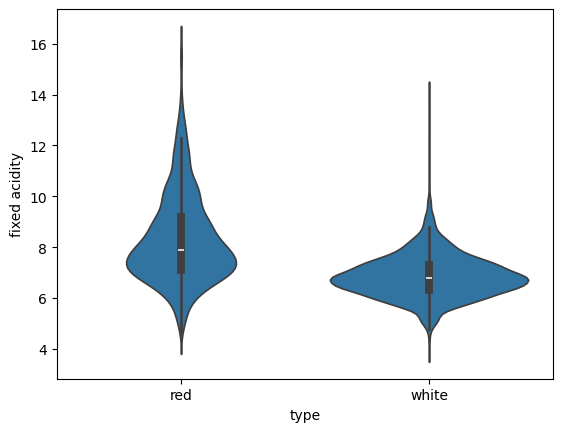

In [25]:
sns.violinplot(x="type", y="fixed acidity", data=df)
plt.show()

### Volatile acidity

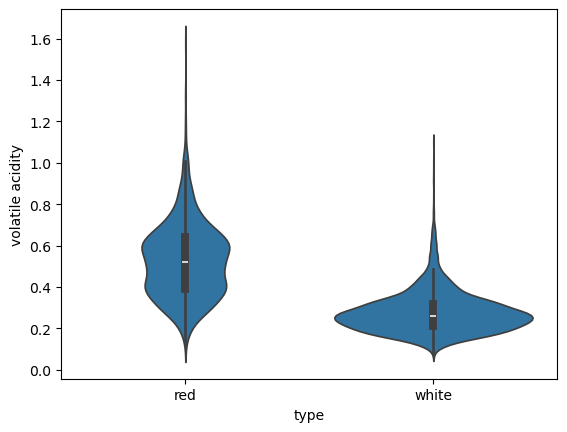

In [26]:
sns.violinplot(x="type", y="volatile acidity", data=df)
plt.show()

### Citric acid

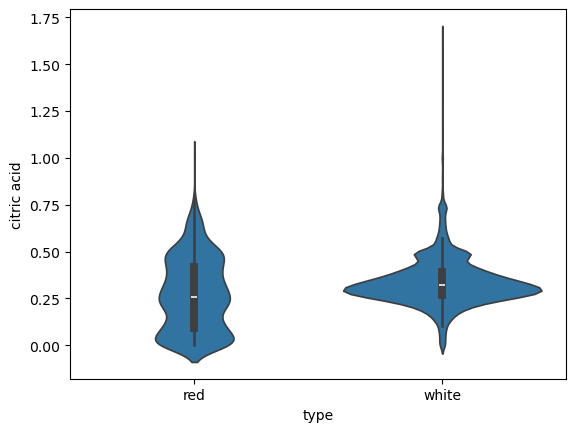

In [27]:
sns.violinplot(x="type", y="citric acid", data=df)
plt.show()

### Residual Sugar

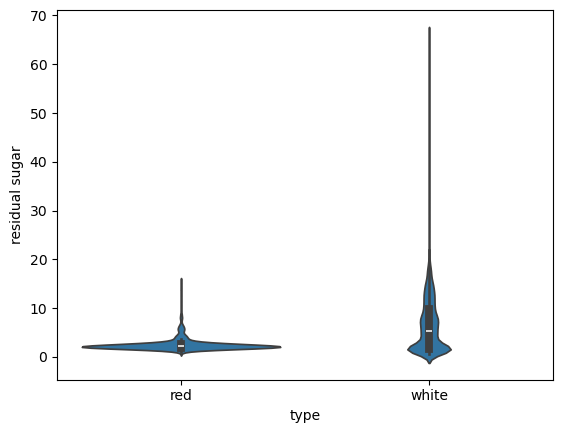

In [28]:
sns.violinplot(x="type", y="residual sugar", data=df)
plt.show()

### Chlorides

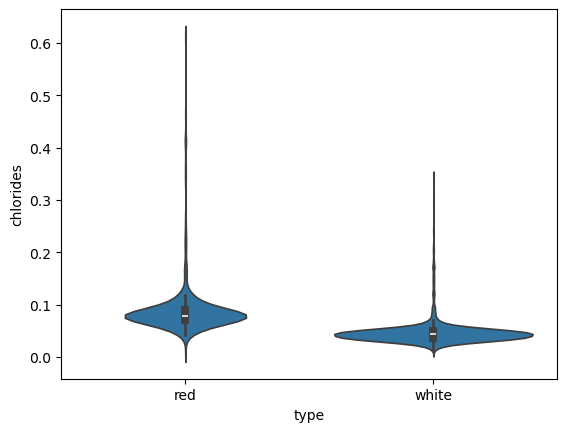

In [29]:
sns.violinplot(x="type", y="chlorides", data=df)
plt.show()

### Free sulfur dioxide

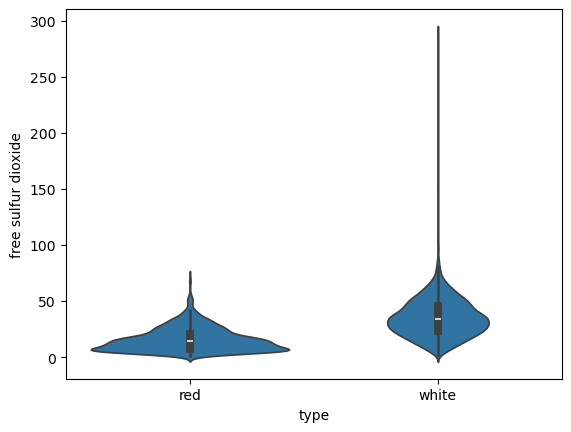

In [30]:
sns.violinplot(x="type", y="free sulfur dioxide", data=df)
plt.show()

### Total sulfur dioxide

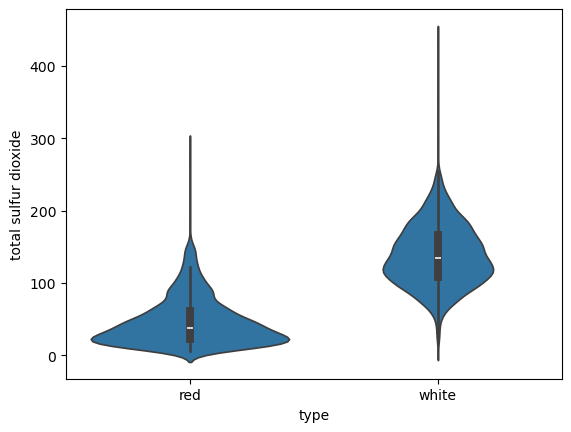

In [31]:
sns.violinplot(x="type", y="total sulfur dioxide", data=df)
plt.show()

### Density

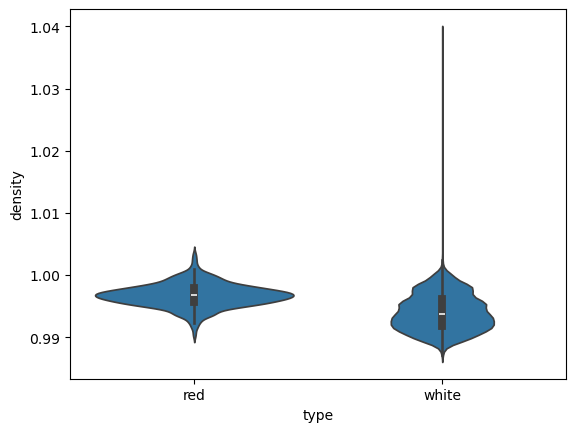

In [32]:
sns.violinplot(x="type", y="density", data=df)
plt.show()

### pH

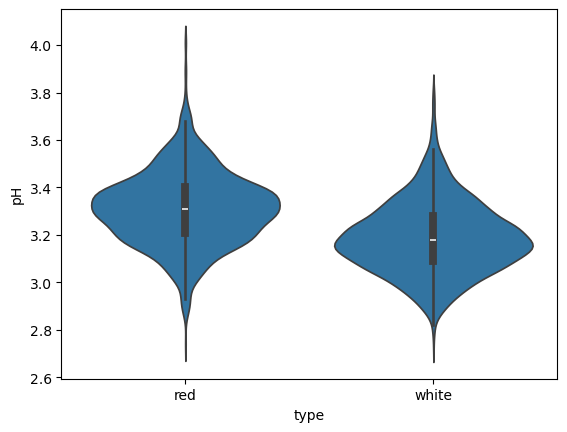

In [33]:
sns.violinplot(x="type", y="pH", data=df)
plt.show()

### Sulphates

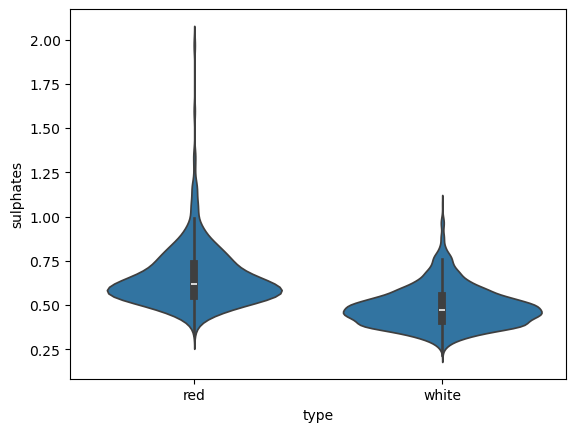

In [34]:
sns.violinplot(x="type", y="sulphates", data=df)
plt.show()

# Pairplots for possible segmentation

### By Type

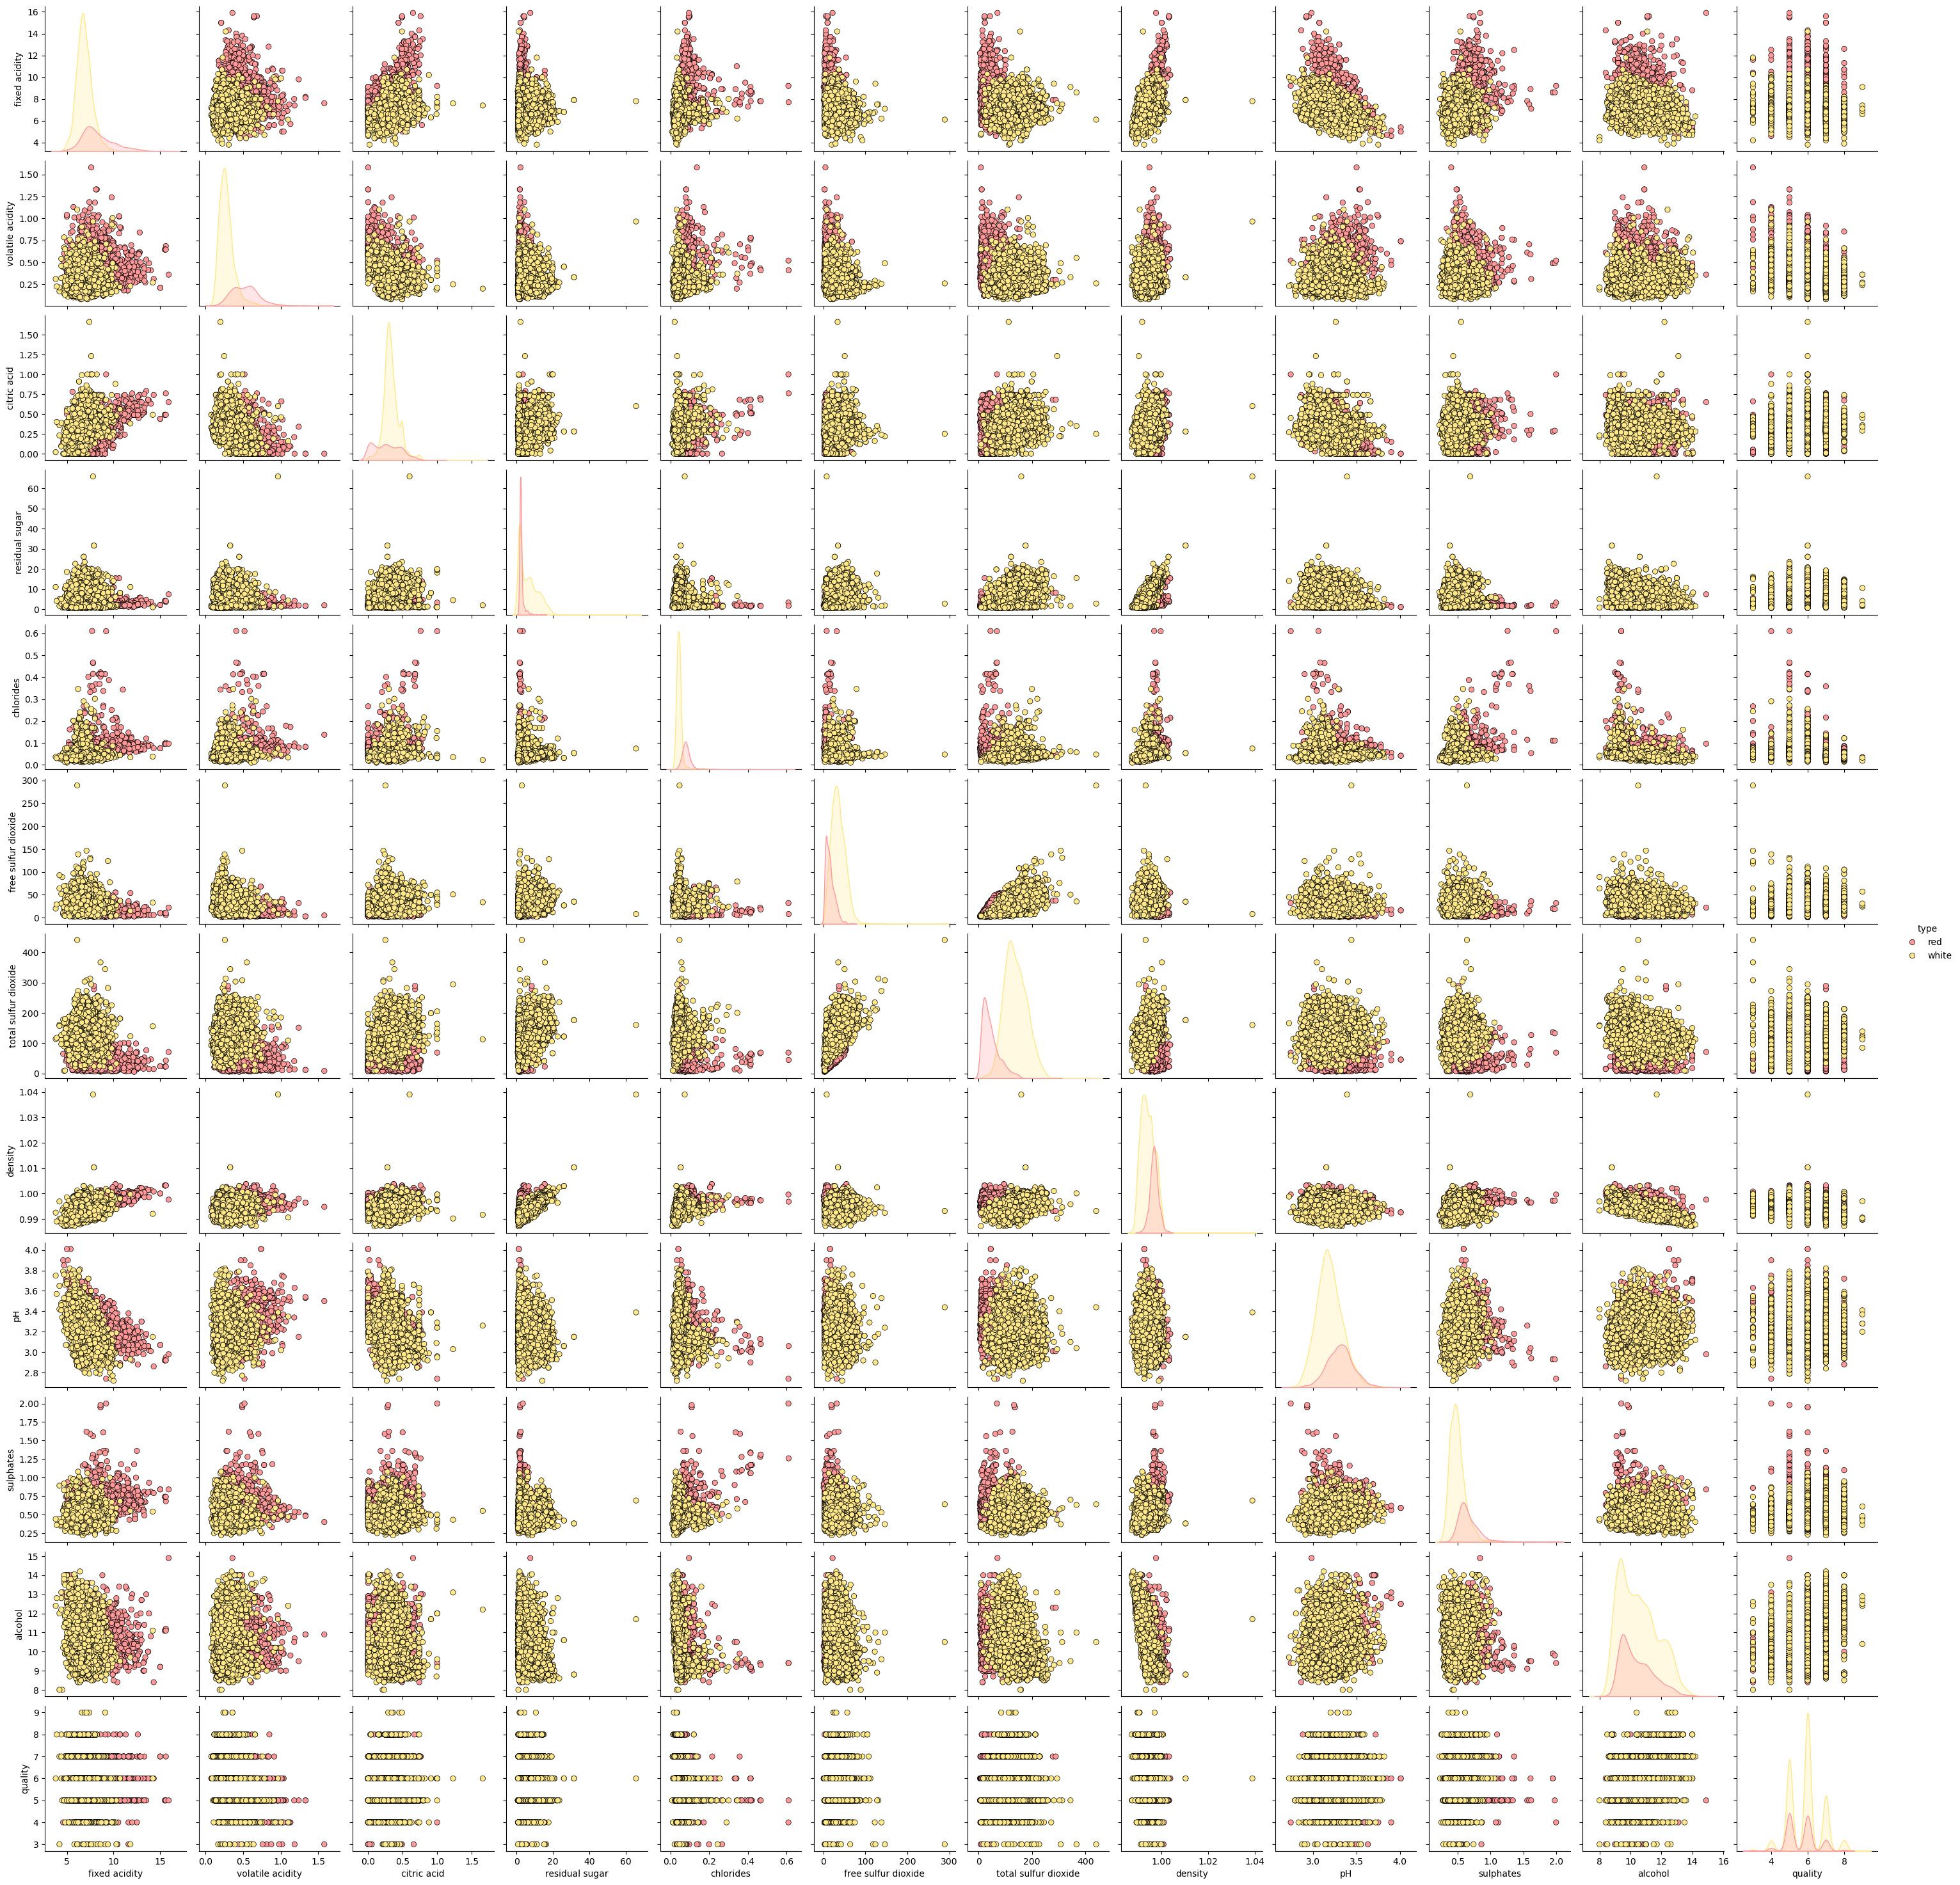

In [35]:
sns.pairplot(df, hue='type',palette={'red': '#FF9999', 'white': '#FFE888'}, plot_kws=dict(edgecolor='black', linewidth=0.5))

In [42]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [90]:
# Step 1: get the data
 
X = df.drop(columns=['quality','type'])
y = df['type']
 
# Step 2: split the data
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
 
# Step 3: Instantiate the model, define the learning parameter, say number of neighbor
 
knn = KNeighborsClassifier(n_neighbors=3)
 
# Step 4: Fit the model using the training data and testing target
 
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [91]:
# Step 5: Test the model
 
y_test_pred = knn.predict(X_test)
print("Test set predictions:\n {}".format(y_test_pred))

Test set predictions:
 ['red' 'white' 'red' ... 'white' 'white' 'white']


In [92]:
# Step 6: Determine accuracy
 
print("Test set score: {:.4f}".format(knn.score(X_test, y_test)))

Test set score: 0.9409


In [ ]:
X = df.drop(columns=['quality', 'type'])  
y = df['type']  # target

lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()

for seedN in range(1, 20, 1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seedN
    )

    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50, 1)  # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train))
        test_accuracy.append(clf.score(X_test, y_test))

    lahat_training[seedN] = training_accuracy
    lahat_test[seedN] = test_accuracy

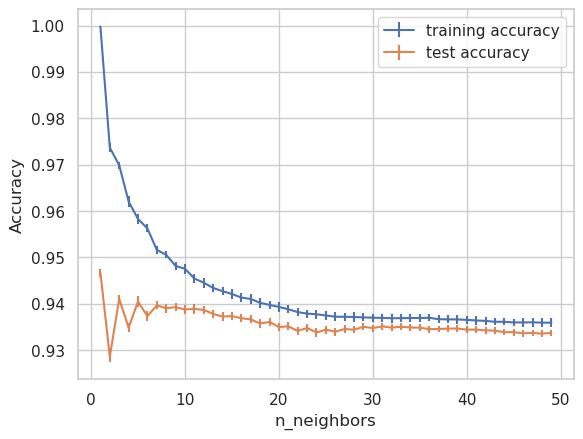

In [76]:
plt.errorbar(neighbors_settings, lahat_training.mean(axis=1),
             yerr=lahat_training.std(axis=1)/2, label="training accuracy")
plt.errorbar(neighbors_settings, lahat_test.mean(axis=1),
             yerr=lahat_test.std(axis=1)/6, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [77]:
print("Best test set mean accuracy: {:.2f}%".format(lahat_test.mean(axis = 1).max() * 100))
print("For k = {}".format(lahat_test.mean(axis = 1).argmax() + 1))

Best test set mean accuracy: 94.67%
For k = 1


**<u>REFERENCES</u>:**

[1] Mohais, A., Schellenberg, S., Ibrahimov, M., Wagner, N., & Michalewicz, Z. (2011). An Evolutionary Approach to practical constraints in Scheduling: A Case-Study of the Wine Bottling Problem. In Springer eBooks (pp. 31–58). https://doi.org/10.1007/978-3-642-23424-8_2

[2] Cholette, S. (2011). Postponement Practices in the Wine Industry: Comparison of Adaptation and Attitudes between California and Bordeaux.

[3] Moccia, Luigi. (2013). Operational Research in the Wine Supply Chain. INFOR: Information Systems and Operational Research. 51. 53-63. 10.3138/infor.51.2.53. 

<img src="images/bottom_banner_ML1_HW1.png" style="width: 100%;">